# Opciones lookback

Tercera familia de opciones sobre la misma simulación. Ahora el payoff depende
del extremo alcanzado por la trayectoria.

| Tipo | Call | Put |
|---|---|---|
| Europea | $\max(S_T - K, 0)$ | $\max(K - S_T, 0)$ |
| Asiática | $\max(\hat{S} - K, 0)$ | $\max(K - \hat{S}, 0)$ |
| Lookback | $S_T - \min(S_t)$ | $\max(S_t) - S_T$ |

La lookback es de **strike flotante**: no hay un precio de ejercicio pactado,
el strike se determina al final en el mejor nivel observado. Por eso el
parámetro K no interviene en su cálculo.

El payoff nunca es negativo, porque el precio final siempre queda entre el
mínimo y el máximo de su propia trayectoria.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (11, 5)


def create_paths(S0, r, sigma, T, n, M):
    """Genera M trayectorias con n pasos. Devuelve matriz (M, n+1)."""
    dt = T / n
    Z = np.random.normal(0, 1, (M, n))
    
    S = np.zeros((M, n + 1))
    S[:, 0] = S0
    
    for t in range(1, n + 1):
        S[:, t] = S[:, t-1] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[:, t-1])
    
    return S


def payoff_europeo(paths, K, call=True):
    """Usa solo el precio final."""
    ST = paths[:, -1]
    if call:
        return np.maximum(ST - K, 0)
    return np.maximum(K - ST, 0)


def payoff_asiatica(paths, K, call=True):
    """Usa el promedio de la trayectoria. Excluye S0."""
    S_hat = paths[:, 1:].mean(axis=1)
    if call:
        return np.maximum(S_hat - K, 0)
    return np.maximum(K - S_hat, 0)


def payoff_lookback(paths, K, call=True):
    """Strike flotante: usa el extremo de la trayectoria. K no se utiliza."""
    ST = paths[:, -1]
    if call:
        return ST - paths[:, 1:].min(axis=1)
    return paths[:, 1:].max(axis=1) - ST

In [15]:
S0, K, r, sigma, T = 100, 100, 0.05, 0.20, 1
n, M = 252, 1000

np.random.seed(42)
paths = create_paths(S0, r, sigma, T, n, M)
descuento = np.exp(-r*T)

funciones = [
    ('Europea',  payoff_europeo),
    ('Asiática', payoff_asiatica),
    ('Lookback', payoff_lookback),
]

filas = []
payoffs = {}

for nombre, f in funciones:
    for tipo, es_call in [('Call', True), ('Put', False)]:
        pay = f(paths, K, call=es_call)
        payoffs[(nombre, tipo)] = pay
        filas.append({
            'Opción': f'{tipo} {nombre.lower()}',
            'Payoff promedio': pay.mean(),
            'Precio': descuento * pay.mean(),
            'P(payoff > 0)': (pay > 0).mean(),
            'Desv. est.': pay.std(ddof=1),
            'Payoff máximo': pay.max()
        })

resumen = pd.DataFrame(filas)
print(resumen.round(4).to_string(index=False))

       Opción  Payoff promedio  Precio  P(payoff > 0)  Desv. est.  Payoff máximo
 Call europea          10.8925 10.3612          0.575     14.9153        79.3853
  Put europea           5.8058  5.5227          0.425      9.0941        45.8355
Call asiática           5.8699  5.5837          0.564      8.2024        43.1923
 Put asiática           3.6627  3.4841          0.436      5.7681        27.0949
Call lookback          17.5812 16.7238          0.981     14.9083        90.3421
 Put lookback          13.7872 13.1147          0.956     10.3137        49.2188


In [16]:
S_min = paths[:, 1:].min(axis=1)
S_max = paths[:, 1:].max(axis=1)
S_hat = paths[:, 1:].mean(axis=1)
ST    = paths[:, -1]

print(f"{'':10} {'Media':>9} {'Mínimo':>9} {'Máximo':>9}")
print(f"{'min(S_t)':10} {S_min.mean():>9.2f} {S_min.min():>9.2f} {S_min.max():>9.2f}")
print(f"{'S_hat':10} {S_hat.mean():>9.2f} {S_hat.min():>9.2f} {S_hat.max():>9.2f}")
print(f"{'S_T':10} {ST.mean():>9.2f} {ST.min():>9.2f} {ST.max():>9.2f}")
print(f"{'max(S_t)':10} {S_max.mean():>9.2f} {S_max.min():>9.2f} {S_max.max():>9.2f}")

               Media    Mínimo    Máximo
min(S_t)       87.51     49.28    104.46
S_hat         102.21     72.91    143.19
S_T           105.09     54.16    179.39
max(S_t)      118.87     97.76    183.75


### Grafica Trayectoria con las 3 referencias

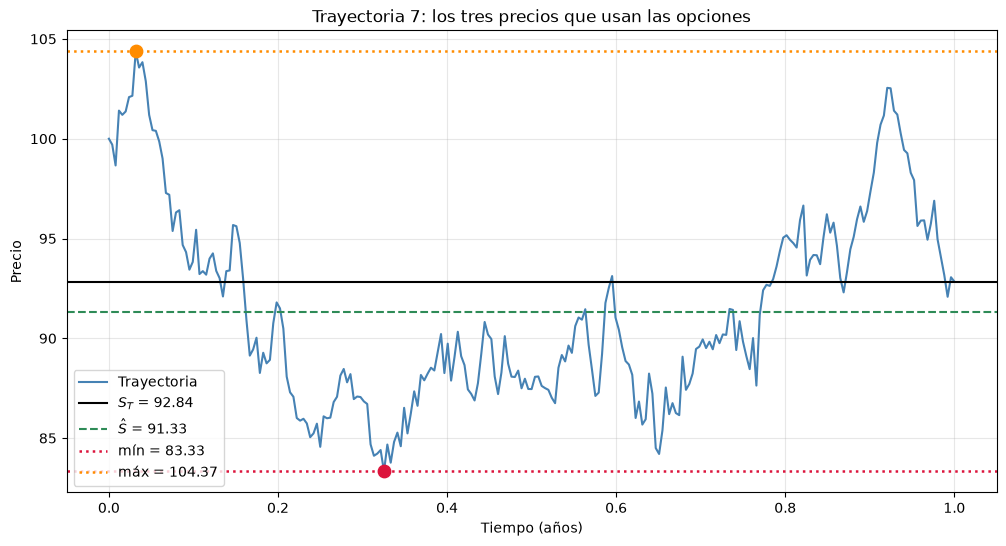

In [17]:
i = 7
tiempo = np.linspace(0, T, n + 1)
tr = paths[i, :]
idx_min = tr[1:].argmin() + 1
idx_max = tr[1:].argmax() + 1

plt.figure(figsize=(12, 6))
plt.plot(tiempo, tr, lw=1.5, color='steelblue', label='Trayectoria')

plt.axhline(tr[-1], color='black', ls='-',  lw=1.5, label=f'$S_T$ = {tr[-1]:.2f}')
plt.axhline(S_hat[i], color='seagreen', ls='--', lw=1.5, label=f'$\\hat{{S}}$ = {S_hat[i]:.2f}')
plt.axhline(tr[idx_min], color='crimson', ls=':', lw=1.8, label=f'mín = {tr[idx_min]:.2f}')
plt.axhline(tr[idx_max], color='darkorange', ls=':', lw=1.8, label=f'máx = {tr[idx_max]:.2f}')

plt.scatter([tiempo[idx_min]], [tr[idx_min]], color='crimson', s=80, zorder=5)
plt.scatter([tiempo[idx_max]], [tr[idx_max]], color='darkorange', s=80, zorder=5)

plt.xlabel('Tiempo (años)'); plt.ylabel('Precio')
plt.title(f'Trayectoria {i}: los tres precios que usan las opciones')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### Histograma de payoffs

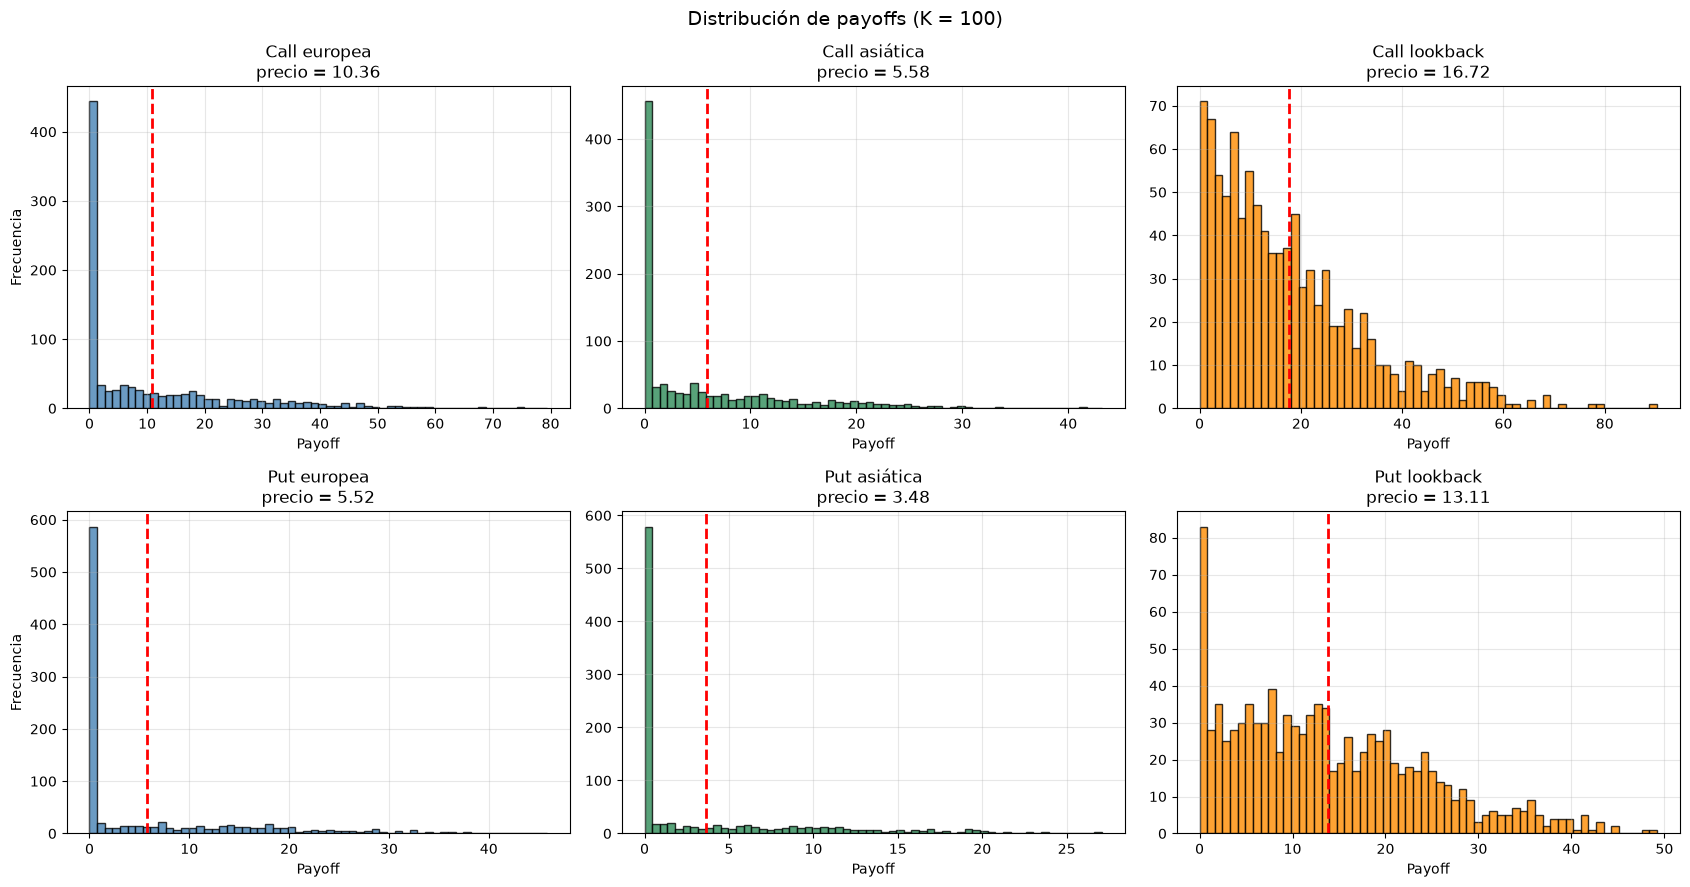

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

colores = {'Europea': 'steelblue', 'Asiática': 'seagreen', 'Lookback': 'darkorange'}

for j, (nombre, _) in enumerate(funciones):
    for i, tipo in enumerate(['Call', 'Put']):
        pay = payoffs[(nombre, tipo)]
        ax = axes[i, j]
        ax.hist(pay, bins=60, color=colores[nombre], edgecolor='black', alpha=0.8)
        ax.axvline(pay.mean(), color='red', ls='--', lw=2)
        ax.set_title(f'{tipo} {nombre.lower()}\nprecio = {descuento*pay.mean():.2f}')
        ax.set_xlabel('Payoff')
        ax.grid(alpha=0.3)

axes[0, 0].set_ylabel('Frecuencia')
axes[1, 0].set_ylabel('Frecuencia')
plt.suptitle(f'Distribución de payoffs (K = {K})', fontsize=14)
plt.tight_layout()
plt.show()

### Comparacion de Precios

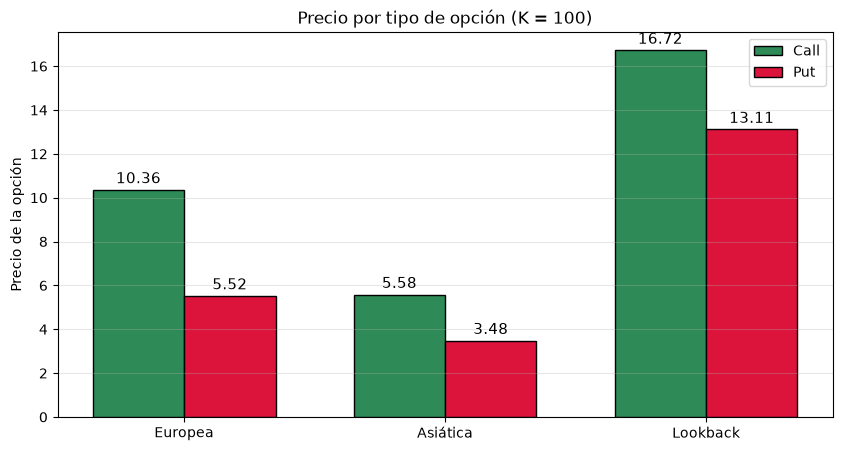

In [19]:
tipos = ['Europea', 'Asiática', 'Lookback']
precios_call = [descuento * payoffs[(t, 'Call')].mean() for t in tipos]
precios_put  = [descuento * payoffs[(t, 'Put')].mean()  for t in tipos]

x = np.arange(len(tipos))
ancho = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - ancho/2, precios_call, ancho, color='seagreen', edgecolor='black', label='Call')
plt.bar(x + ancho/2, precios_put,  ancho, color='crimson',  edgecolor='black', label='Put')

for i, (c, p) in enumerate(zip(precios_call, precios_put)):
    plt.text(i - ancho/2, c + 0.3, f'{c:.2f}', ha='center', fontsize=11)
    plt.text(i + ancho/2, p + 0.3, f'{p:.2f}', ha='center', fontsize=11)

plt.xticks(x, tipos)
plt.ylabel('Precio de la opción')
plt.title(f'Precio por tipo de opción (K = {K})')
plt.legend(); plt.grid(alpha=0.3, axis='y')
plt.show()

# Opciones con barrera

Una barrera es un nivel $B$ que activa o desactiva la opción según si el precio
lo toca durante la vida del contrato. El payoff base no cambia: lo que cambia es
si se cobra o no.

| Tipo | Condición | Resultado |
|---|---|---|
| **Down and out** | $\min(S_t) \leq B$ | Se desactiva, paga 0 |
| **Down and in** | $\min(S_t) \leq B$ | Se activa, paga normal |
| **Up and out** | $\max(S_t) \geq B$ | Se desactiva, paga 0 |
| **Up and in** | $\max(S_t) \geq B$ | Se activa, paga normal |

Las funciones reciben la función de payoff como argumento, así que la barrera
se puede aplicar sobre cualquiera de los tres tipos que ya se programaron.

**Relación fundamental:** una knock-in y una knock-out con la misma barrera
suman exactamente el valor de la opción sin barrera. Cada trayectoria toca o no
toca, nunca ambas, así que entre las dos se reparten todos los escenarios.

$$V_{\text{in}} + V_{\text{out}} = V_{\text{vanilla}}$$

In [20]:
# definiendo funciones

def down_and_out(B, payoff, paths, K, call=True):
    """Se desactiva si el precio toca B por abajo."""
    p = payoff(paths, K, call)
    toco = paths[:, 1:].min(axis=1) <= B
    return np.where(toco, 0.0, p)


def down_and_in(B, payoff, paths, K, call=True):
    """Solo se activa si el precio toca B por abajo."""
    p = payoff(paths, K, call)
    toco = paths[:, 1:].min(axis=1) <= B
    return np.where(toco, p, 0.0)


def up_and_out(B, payoff, paths, K, call=True):
    """Se desactiva si el precio toca B por arriba."""
    p = payoff(paths, K, call)
    toco = paths[:, 1:].max(axis=1) >= B
    return np.where(toco, 0.0, p)


def up_and_in(B, payoff, paths, K, call=True):
    """Solo se activa si el precio toca B por arriba."""
    p = payoff(paths, K, call)
    toco = paths[:, 1:].max(axis=1) >= B
    return np.where(toco, p, 0.0)

In [21]:
S0, K, r, sigma, T = 100, 100, 0.05, 0.20, 1
n, M = 252, 1000

B_abajo = 90
B_arriba = 120

np.random.seed(42)
paths = create_paths(S0, r, sigma, T, n, M)
descuento = np.exp(-r*T)

S_min = paths[:, 1:].min(axis=1)
S_max = paths[:, 1:].max(axis=1)

print(f"P(tocar {B_abajo} por abajo)  : {(S_min <= B_abajo).mean():.3f}")
print(f"P(tocar {B_arriba} por arriba) : {(S_max >= B_arriba).mean():.3f}")

P(tocar 90 por abajo)  : 0.534
P(tocar 120 por arriba) : 0.379


In [22]:
tipos_payoff = [
    ('Europea',  payoff_europeo),
    ('Asiática', payoff_asiatica),
    ('Lookback', payoff_lookback),
]

filas = []

for nombre, fp in tipos_payoff:
    for tipo, es_call in [('Call', True), ('Put', False)]:
        vanilla = descuento * fp(paths, K, es_call).mean()
        do = descuento * down_and_out(B_abajo,  fp, paths, K, es_call).mean()
        di = descuento * down_and_in(B_abajo,   fp, paths, K, es_call).mean()
        uo = descuento * up_and_out(B_arriba,   fp, paths, K, es_call).mean()
        ui = descuento * up_and_in(B_arriba,    fp, paths, K, es_call).mean()

        filas.append({
            'Tipo': f'{tipo} {nombre.lower()}',
            'Sin barrera': vanilla,
            f'D&O ({B_abajo})': do,
            f'D&I ({B_abajo})': di,
            'D&O + D&I': do + di,
            f'U&O ({B_arriba})': uo,
            f'U&I ({B_arriba})': ui,
            'U&O + U&I': uo + ui,
        })

tabla = pd.DataFrame(filas)
print(tabla.round(4).to_string(index=False))

         Tipo  Sin barrera  D&O (90)  D&I (90)  D&O + D&I  U&O (120)  U&I (120)  U&O + U&I
 Call europea      10.3612    8.5072    1.8541    10.3612     1.5330     8.8283    10.3612
  Put europea       5.5227    0.1794    5.3433     5.5227     5.3546     0.1681     5.5227
Call asiática       5.5837    5.1225    0.4611     5.5837     0.6318     4.9519     5.5837
 Put asiática       3.4841    0.0135    3.4707     3.4841     3.4779     0.0062     3.4841
Call lookback      16.7238   10.3422    6.3816    16.7238     6.1436    10.5801    16.7238
 Put lookback      13.1147    4.6276    8.4872    13.1147     9.0877     4.0271    13.1147


In [23]:
err_down = (tabla['D&O + D&I'] - tabla['Sin barrera']).abs().max()
err_up   = (tabla['U&O + U&I'] - tabla['Sin barrera']).abs().max()

print(f"Error máximo en la paridad down : {err_down:.2e}")
print(f"Error máximo en la paridad up   : {err_up:.2e}")

Error máximo en la paridad down : 1.78e-15
Error máximo en la paridad up   : 1.78e-15


In [24]:
def precio_opcion(S0, K, r, sigma, T, n, M, payoff=payoff_europeo,
                  call=True, barrera=None, B=None, seed=42):
    """
    Precio justo de cualquier combinación vista en el curso.

    payoff  : payoff_europeo, payoff_asiatica o payoff_lookback
    barrera : None, down_and_out, down_and_in, up_and_out o up_and_in
    """
    np.random.seed(seed)
    paths = create_paths(S0, r, sigma, T, n, M)

    if barrera is None:
        p = payoff(paths, K, call)
    else:
        p = barrera(B, payoff, paths, K, call)

    precio = np.exp(-r*T) * p.mean()
    se = np.exp(-r*T) * p.std(ddof=1) / np.sqrt(M)
    return precio, se


# Ejemplos de uso
p1, se1 = precio_opcion(100, 110, 0.05, 0.20, 1, 252, 1000)
p2, se2 = precio_opcion(100, 110, 0.05, 0.20, 1, 252, 1000,
                        payoff=payoff_asiatica, barrera=down_and_out, B=90)
p3, se3 = precio_opcion(100, 110, 0.05, 0.20, 1, 252, 1000,
                        payoff=payoff_lookback, call=False,
                        barrera=up_and_in, B=120)

print(f"Call europea sin barrera        : {p1:.4f}  (SE {se1:.4f})")
print(f"Call asiática down-and-out (90) : {p2:.4f}  (SE {se2:.4f})")
print(f"Put lookback up-and-in (120)    : {p3:.4f}  (SE {se3:.4f})")

Call europea sin barrera        : 5.8694  (SE 0.3509)
Call asiática down-and-out (90) : 1.8415  (SE 0.1476)
Put lookback up-and-in (120)    : 4.0271  (SE 0.2418)


### Visualizacion de trayectorias

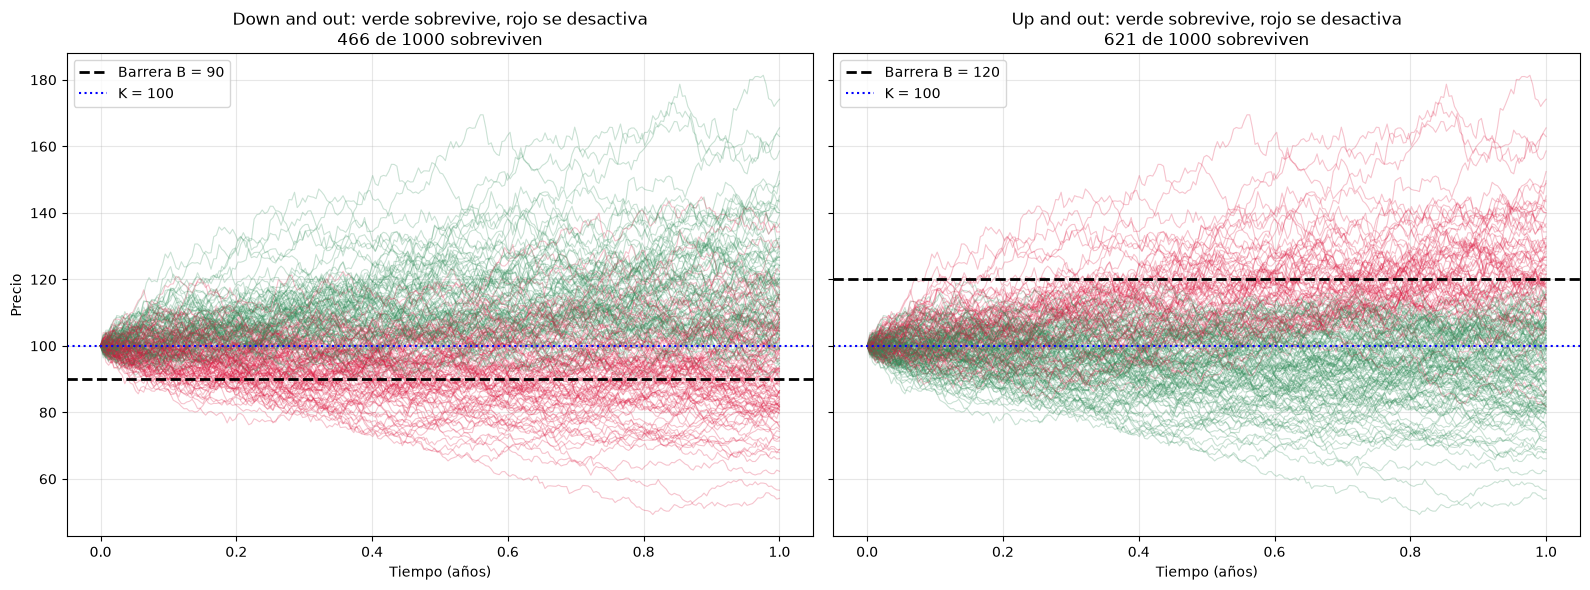

In [25]:
tiempo = np.linspace(0, T, n + 1)
toco_abajo = S_min <= B_abajo

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for i in range(200):
    if toco_abajo[i]:
        axes[0].plot(tiempo, paths[i, :], color='crimson', alpha=0.25, lw=0.8)
    else:
        axes[0].plot(tiempo, paths[i, :], color='seagreen', alpha=0.25, lw=0.8)

axes[0].axhline(B_abajo, color='black', ls='--', lw=2, label=f'Barrera B = {B_abajo}')
axes[0].axhline(K, color='blue', ls=':', lw=1.5, label=f'K = {K}')
axes[0].set_xlabel('Tiempo (años)'); axes[0].set_ylabel('Precio')
axes[0].set_title(f'Down and out: verde sobrevive, rojo se desactiva\n'
                  f'{(~toco_abajo).sum()} de {M} sobreviven')
axes[0].legend(); axes[0].grid(alpha=0.3)

toco_arriba = S_max >= B_arriba
for i in range(200):
    if toco_arriba[i]:
        axes[1].plot(tiempo, paths[i, :], color='crimson', alpha=0.25, lw=0.8)
    else:
        axes[1].plot(tiempo, paths[i, :], color='seagreen', alpha=0.25, lw=0.8)

axes[1].axhline(B_arriba, color='black', ls='--', lw=2, label=f'Barrera B = {B_arriba}')
axes[1].axhline(K, color='blue', ls=':', lw=1.5, label=f'K = {K}')
axes[1].set_xlabel('Tiempo (años)')
axes[1].set_title(f'Up and out: verde sobrevive, rojo se desactiva\n'
                  f'{(~toco_arriba).sum()} de {M} sobreviven')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Precio en función del nivel de barrera

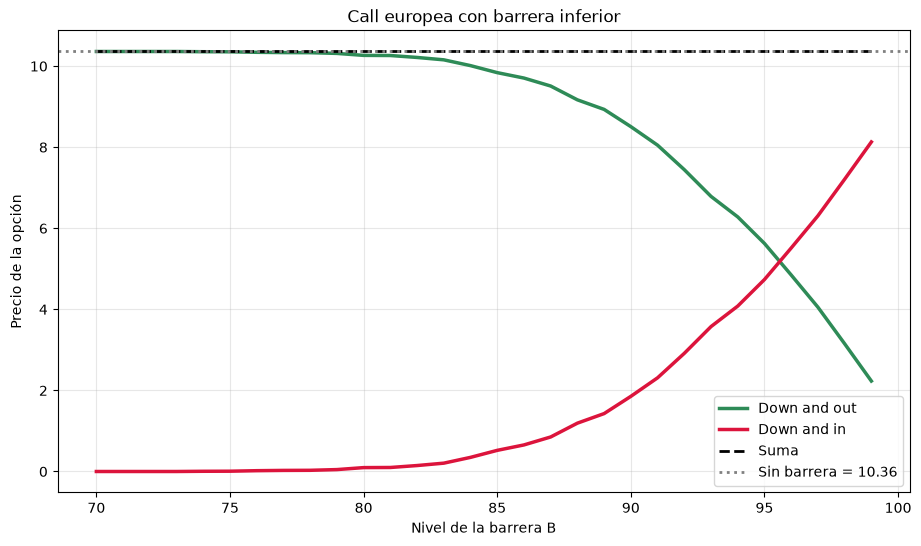

In [26]:
niveles = np.linspace(70, 99, 30)

do_call = [descuento * down_and_out(b, payoff_europeo, paths, K, True).mean() for b in niveles]
di_call = [descuento * down_and_in(b,  payoff_europeo, paths, K, True).mean() for b in niveles]
vanilla = descuento * payoff_europeo(paths, K, True).mean()

plt.figure(figsize=(11, 6))
plt.plot(niveles, do_call, lw=2.5, color='seagreen', label='Down and out')
plt.plot(niveles, di_call, lw=2.5, color='crimson', label='Down and in')
plt.plot(niveles, np.array(do_call) + np.array(di_call), lw=2, ls='--',
         color='black', label='Suma')
plt.axhline(vanilla, color='gray', ls=':', lw=2, label=f'Sin barrera = {vanilla:.2f}')

plt.xlabel('Nivel de la barrera B')
plt.ylabel('Precio de la opción')
plt.title('Call europea con barrera inferior')
plt.legend(); plt.grid(alpha=0.3)
plt.show()